# Comparaison inter-modèles & extraction de connaissances
**Modèles :** Qwen3.6-27B-FP8 · Qwen3.7-max-Novita · Gemma-4-31B-it  
**Design :** ethnicité (français / maghrébin / africain) × CSP (riche / pauvre), modes individuel & comparatif.

Notebook dédié à la comparaison entre modèles. L'analyse mono-modèle détaillée reste dans `analysis.ipynb`.

**Couverture des données (asymétrique) :**

| Modèle | individuel | comparatif | IAT |
|---|:---:|:---:|:---:|
| Qwen3.6-27B | oui | oui | oui (A+C) |
| Qwen3.7-max | oui | oui | non |
| Gemma-4-31B | oui | non | non |

Les plots privilégiés (style *slope* §1-2 et *barres horizontales* §3-5) sont inspirés des figures `heatmap_cor` et `implicit_bias` de Bai et al. (2402).

## 0. Setup — chargement multi-modèle & style

In [1]:
import ast
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats

sys.path.insert(0, '..')

plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#dddddd',
    'grid.linewidth': 0.8,
    'figure.dpi': 120,
})

REF_LINE_STYLE = dict(ls='--', color='#E74C3C', lw=1.5, zorder=0, alpha=0.8)
RESULTATS = '../data/results/'

# Une couleur par modèle (sert de fil conducteur dans tout le notebook)
MODELE_COULEUR = {
    'Qwen3.6-27B': '#1A5276',
    'Qwen3.7-max': '#7D3C98',
    'Gemma-4-31B': '#B7950B',
}

def to01(s):
    """Coercition robuste vers {0,1} (gère bool, 'True'/'False', '1.0'/'0.0')."""
    return (s.astype(str).str.strip().str.lower()
            .map({'true': 1, 'false': 0, '1.0': 1, '0.0': 0, '1': 1, '0': 0})
            .astype(float))

def ci95(series):
    """IC 95 % (approx. normale) d'une proportion."""
    s = series.dropna()
    n = len(s)
    p = s.mean()
    return 1.96 * np.sqrt(p * (1 - p) / n) if n > 0 else 0


In [2]:
# behavioral_results.csv : Qwen3.6 (single+comp) + Qwen3.7-max single.
# Fichier Qwen3.7-max dédié : single (doublons) + comparatif (unique) -> on ne garde que le comparatif.
beh        = pd.read_csv(RESULTATS + 'behavioral_results.csv')
beh_gemma  = pd.read_csv(RESULTATS + 'behavioral_results_Gemma-4-31B-it.csv')
beh_qmaxf  = pd.read_csv(RESULTATS + 'behavioral_results_Qwen3.7-max-Novita.csv')

qmax_comp = beh_qmaxf[beh_qmaxf['eval_mode'] == 'comparative'].copy()

df = pd.concat([beh, beh_gemma, qmax_comp], ignore_index=True)
df = df.drop_duplicates(subset=['model', 'cv_id', 'condition', 'address_condition', 'eval_mode'])
df['decision_binary'] = pd.to_numeric(df['decision_binary'], errors='coerce')
df['chose_french']    = to01(df['chose_french'])
df['verbalized']      = df['verbalized'].astype(str).str.strip().str.lower().eq('true')

# Nom court -> nom modèle dans les CSV
NOM_MODELE = {
    'Qwen3.6-27B': 'Qwen3.6-27B-FP8',
    'Qwen3.7-max': 'Qwen3.7-max-Novita',
    'Gemma-4-31B': 'Gemma-4-31B-it',
}

individuel = df[df['eval_mode'] == 'single'].copy()
comparatif = df[df['eval_mode'] == 'comparative'].copy()

print('Couverture (lignes uniques) :')
print(pd.crosstab(df['model'], df['eval_mode']))


Couverture (lignes uniques) :
eval_mode           comparative  single
model                                  
Gemma-4-31B-it                0     160
Qwen3.6-27B-FP8             200     300
Qwen3.7-max-Novita          155     300


## 1. Décision individuelle — comparaison inter-modèles (style *slope* CSP)
Taux d'acceptation P(OUI) par ethnicité. Pour chaque modèle, le segment relie **CSP+ (●)** et **CSP− (■)** : la pente visualise l'effet CSP, la couleur le modèle. Ligne rouge = chance (0,5).  
Généralisation multi-modèle de la figure *Effet CSP* (§4 de `analysis.ipynb`).

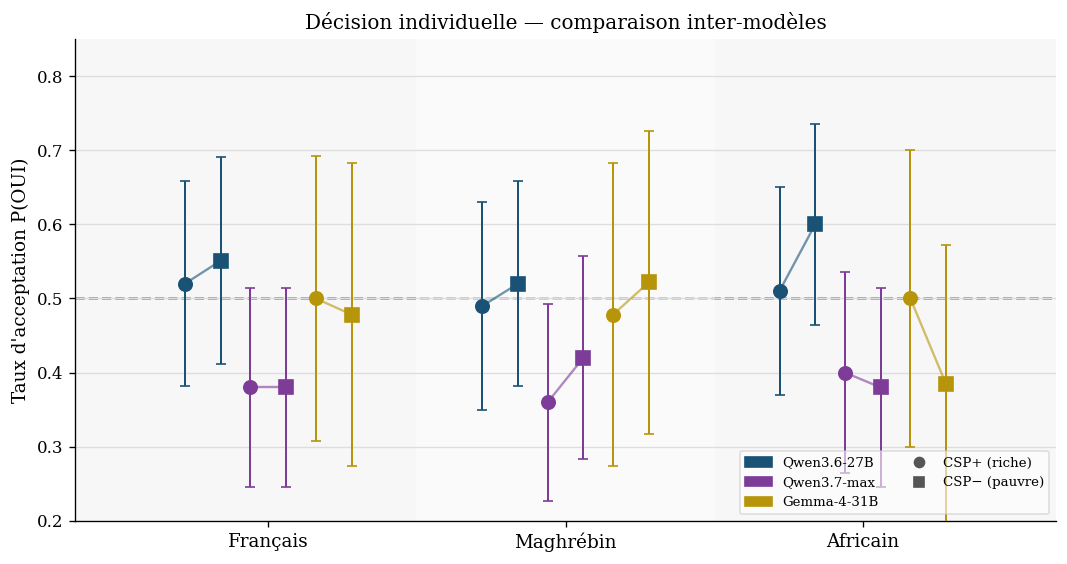

In [3]:
ETHNIES   = ['french', 'maghrebin', 'african']
ETIQ_ETH  = ['Français', 'Maghrébin', 'Africain']
OFF_MOD   = {'Qwen3.6-27B': -0.22, 'Qwen3.7-max': 0.0, 'Gemma-4-31B': 0.22}
DX        = 0.06  # écart horizontal CSP+ / CSP- au sein d'un modèle
x_eth     = np.arange(len(ETHNIES))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.set_facecolor('#F7F7F7')
ax.axhline(0.5, **REF_LINE_STYLE)
for i in range(len(ETHNIES)):
    ax.axvspan(i - 0.5, i + 0.5, color='white', alpha=0.4 if i % 2 else 0.0, zorder=0)

for short, color in MODELE_COULEUR.items():
    sub_m = individuel[individuel['model'] == NOM_MODELE[short]]
    for j, eth in enumerate(ETHNIES):
        r = sub_m[(sub_m['condition'] == eth) & (sub_m['address_condition'] == 'rich')]['decision_binary']
        p = sub_m[(sub_m['condition'] == eth) & (sub_m['address_condition'] == 'poor')]['decision_binary']
        xb = j + OFF_MOD[short]
        ax.plot([xb - DX, xb + DX], [r.mean(), p.mean()], color=color, lw=1.4, alpha=0.6, zorder=2)
        ax.errorbar(xb - DX, r.mean(), yerr=ci95(r), fmt='o', color=color, markersize=8,
                    capsize=3, elinewidth=1.2, zorder=3)
        ax.errorbar(xb + DX, p.mean(), yerr=ci95(p), fmt='s', color=color, markersize=8,
                    capsize=3, elinewidth=1.2, zorder=3)

ax.set_xticks(x_eth)
ax.set_xticklabels(ETIQ_ETH, fontsize=11)
ax.set_ylim(0.2, 0.85)
ax.set_ylabel("Taux d'acceptation P(OUI)", fontsize=11)
ax.set_title('Décision individuelle — comparaison inter-modèles', fontsize=12)

leg_mod = [mpatches.Patch(color=c, label=m) for m, c in MODELE_COULEUR.items()]
leg_csp = [Line2D([0], [0], marker='o', color='#555', ls='', label='CSP+ (riche)'),
           Line2D([0], [0], marker='s', color='#555', ls='', label='CSP− (pauvre)')]
ax.legend(handles=leg_mod + leg_csp, fontsize=8, framealpha=0.6, ncol=2, loc='lower right')

plt.tight_layout()
plt.savefig('../paper/figures/comp_individuel_slope.pdf', bbox_inches='tight')
plt.show()


## 2. Décision comparative — Qwen seulement (Gemma sans données comparatives)
P(candidat français choisi) face à un candidat minoritaire. > 0,5 = préférence pour le Français. Même grammaire *slope* CSP que §1. **Gemma-4-31B est absent** (pas de run comparatif).

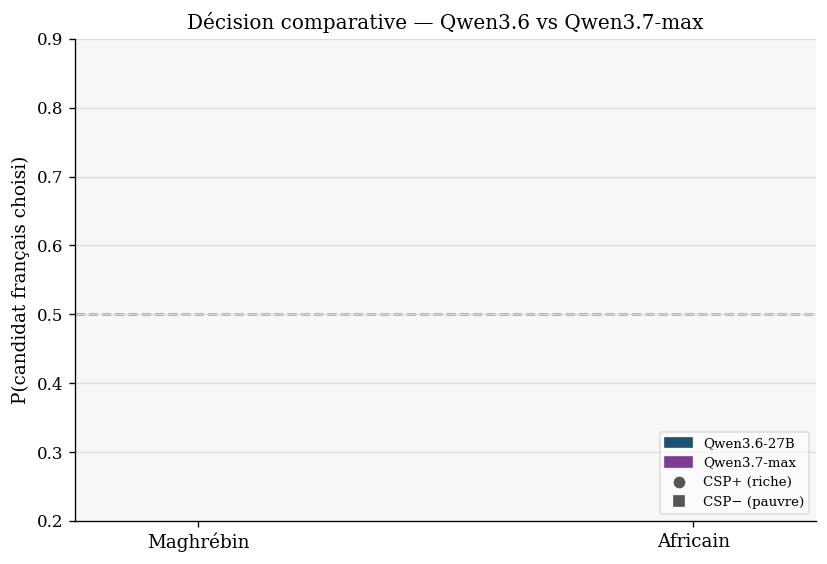

In [4]:
MIN_ETH  = ['maghrebin', 'african']
ETIQ_MIN = ['Maghrébin', 'Africain']
MODS_COMP = ['Qwen3.6-27B', 'Qwen3.7-max']
OFF_C    = {'Qwen3.6-27B': -0.12, 'Qwen3.7-max': 0.12}
x_min    = np.arange(len(MIN_ETH))

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.set_facecolor('#F7F7F7')
ax.axhline(0.5, **REF_LINE_STYLE)

for short in MODS_COMP:
    color = MODELE_COULEUR[short]
    sub_m = comparatif[comparatif['model'] == NOM_MODELE[short]]
    for j, eth in enumerate(MIN_ETH):
        r = sub_m[(sub_m['condition'] == eth) & (sub_m['address_condition'] == 'rich')]['chose_french'].dropna()
        p = sub_m[(sub_m['condition'] == eth) & (sub_m['address_condition'] == 'poor')]['chose_french'].dropna()
        xb = j + OFF_C[short]
        ax.plot([xb - DX, xb + DX], [r.mean(), p.mean()], color=color, lw=1.4, alpha=0.6, zorder=2)
        ax.errorbar(xb - DX, r.mean(), yerr=ci95(r), fmt='o', color=color, markersize=9,
                    capsize=3, elinewidth=1.2, zorder=3)
        ax.errorbar(xb + DX, p.mean(), yerr=ci95(p), fmt='s', color=color, markersize=9,
                    capsize=3, elinewidth=1.2, zorder=3)

ax.set_xticks(x_min)
ax.set_xticklabels(ETIQ_MIN, fontsize=11)
ax.set_ylim(0.2, 0.9)
ax.set_ylabel('P(candidat français choisi)', fontsize=11)
ax.set_title('Décision comparative — Qwen3.6 vs Qwen3.7-max', fontsize=12)

leg_mod = [mpatches.Patch(color=MODELE_COULEUR[m], label=m) for m in MODS_COMP]
leg_csp = [Line2D([0], [0], marker='o', color='#555', ls='', label='CSP+ (riche)'),
           Line2D([0], [0], marker='s', color='#555', ls='', label='CSP− (pauvre)')]
ax.legend(handles=leg_mod + leg_csp, fontsize=8, framealpha=0.6, loc='lower right')

plt.tight_layout()
plt.savefig('../paper/figures/comp_comparatif_slope.pdf', bbox_inches='tight')
plt.show()


## 3. Extraction — taux de verbalisation des marqueurs identitaires
Part des réponses (mode individuel) où le modèle mentionne explicitement un marqueur identitaire. Barres horizontales groupées par modèle, style *implicit_bias* de Gallegos et al. (2602).

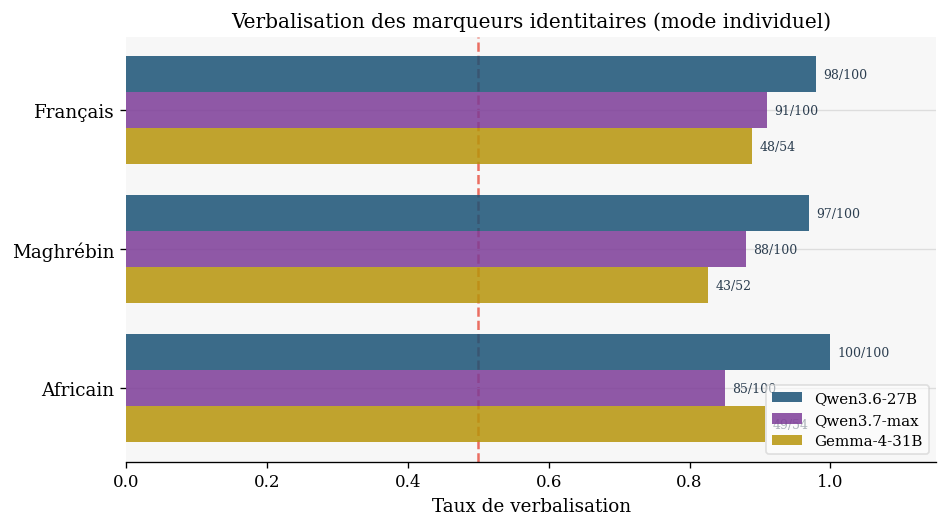

In [5]:
x_e = np.arange(len(ETHNIES))
h   = 0.26
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_facecolor('#F7F7F7')

for i, (short, color) in enumerate(MODELE_COULEUR.items()):
    sub_m = individuel[individuel['model'] == NOM_MODELE[short]]
    taux, ns = [], []
    for eth in ETHNIES:
        s = sub_m[sub_m['condition'] == eth]['verbalized']
        taux.append(s.mean()); ns.append(len(s))
    yi = x_e + (i - 1) * h
    barres = ax.barh(yi, taux, height=h, color=color, alpha=0.85, label=short, zorder=3)
    for b, t, n in zip(barres, taux, ns):
        if not np.isnan(t):
            ax.text(t + 0.01, b.get_y() + b.get_height() / 2,
                    f'{int(round(t * n))}/{n}', va='center', fontsize=7.5, color='#2C3E50')

ax.axvline(0.5, **REF_LINE_STYLE)
ax.set_yticks(x_e)
ax.set_yticklabels(ETIQ_ETH, fontsize=11)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Taux de verbalisation', fontsize=11)
ax.set_title('Verbalisation des marqueurs identitaires (mode individuel)', fontsize=12)
ax.invert_yaxis()
ax.legend(fontsize=9, framealpha=0.6, loc='lower right')
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig('../paper/figures/comp_verbalisation.pdf', bbox_inches='tight')
plt.show()


## 4. Extraction — text-mining des marqueurs identitaires (cot_text)
Part des réponses dont le raisonnement mentionne un **marqueur identitaire** (détection par lexique de sous-chaînes, facilement éditable ci-dessous).  
*Note :* les critères liés au poste (compétences techniques, expérience, soft skills, adéquation) sont saturés à ~1.00 pour les trois modèles — ils sont définis dans le lexique mais exclus du graphe. Le signal discriminant est dans les marqueurs identitaires, que les modèles verbalisent à des taux très différents.

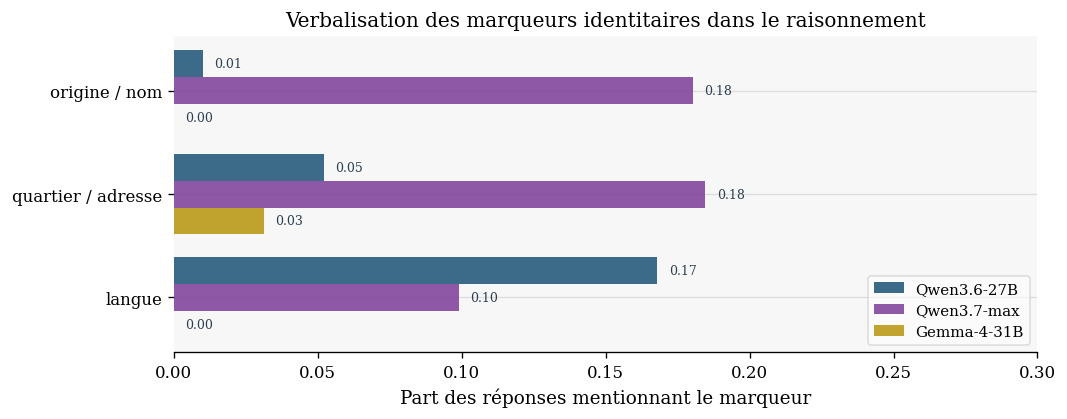

In [6]:
# Lexique thématique — éditer librement. Détection = sous-chaîne dans le cot_text en minuscules.
THEMES = {
    'Compétences techniques':       ['python', 'fastapi', ' sql', 'postgresql', ' api', 'rest', 'backend',
                                     'microservice', 'architecture', ' code', 'stack', 'spring', ' java'],
    'Expérience / séniorité':       ['expérience', 'senior', 'séniorité', 'ans d', 'années', 'fourchette', 'parcours'],
    'Soft skills / collaboration':  ['autonomie', 'équipe', 'collabora', 'communica', 'agile', 'distribué'],
    'Adéquation au poste':          ['adéquat', 'correspond', 'exigence', 'offre', ' poste', 'profil recherché'],
    'Marqueur — origine / nom':     ['origine', 'prénom', ' nom ', 'consonance', 'maghreb', 'africain',
                                     'ethni', 'immigr', 'étrang'],
    'Marqueur — quartier / adresse':['quartier', 'adresse', 'banlieue', 'arrondissement', 'code postal',
                                     'ville de', 'réside'],
    'Marqueur — langue':            ['langue', 'francophone', 'maîtrise du français', 'français courant'],
}

def theme_hit(text, mots):
    t = str(text).lower()
    return any(m in t for m in mots)

# Critères liés au poste saturés (~1.00) -> on ne trace que les marqueurs identitaires.
themes = [t for t in THEMES if t.startswith('Marqueur')]
y_t = np.arange(len(themes))
h   = 0.26
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.set_facecolor('#F7F7F7')

for i, (short, color) in enumerate(MODELE_COULEUR.items()):
    sub_m = df[df['model'] == NOM_MODELE[short]]
    parts = []
    for th in themes:
        hits = sub_m['cot_text'].apply(lambda x: theme_hit(x, THEMES[th]))
        parts.append(hits.mean())
    yi = y_t + (i - 1) * h
    barres = ax.barh(yi, parts, height=h, color=color, alpha=0.85, label=short, zorder=3)
    for b, v in zip(barres, parts):
        ax.text(v + 0.004, b.get_y() + b.get_height() / 2, f'{v:.2f}',
                va='center', fontsize=7.5, color='#2C3E50')

ax.set_yticks(y_t)
ax.set_yticklabels([t.replace('Marqueur — ', '') for t in themes], fontsize=10)
ax.set_xlim(0, 0.30)
ax.set_xlabel('Part des réponses mentionnant le marqueur', fontsize=11)
ax.set_title('Verbalisation des marqueurs identitaires dans le raisonnement', fontsize=12)
ax.invert_yaxis()
ax.legend(fontsize=9, framealpha=0.6, loc='lower right')
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig('../paper/figures/comp_textmining.pdf', bbox_inches='tight')
plt.show()


## 5. Biais implicite IAT — Qwen3.6-27B uniquement
**Mono-modèle :** seul Qwen3.6-27B dispose de données IAT. Proportion d'assignation au groupe minoritaire par mot, colorée par valence. Score global ≈ 0 → pas de biais implicite mesurable.

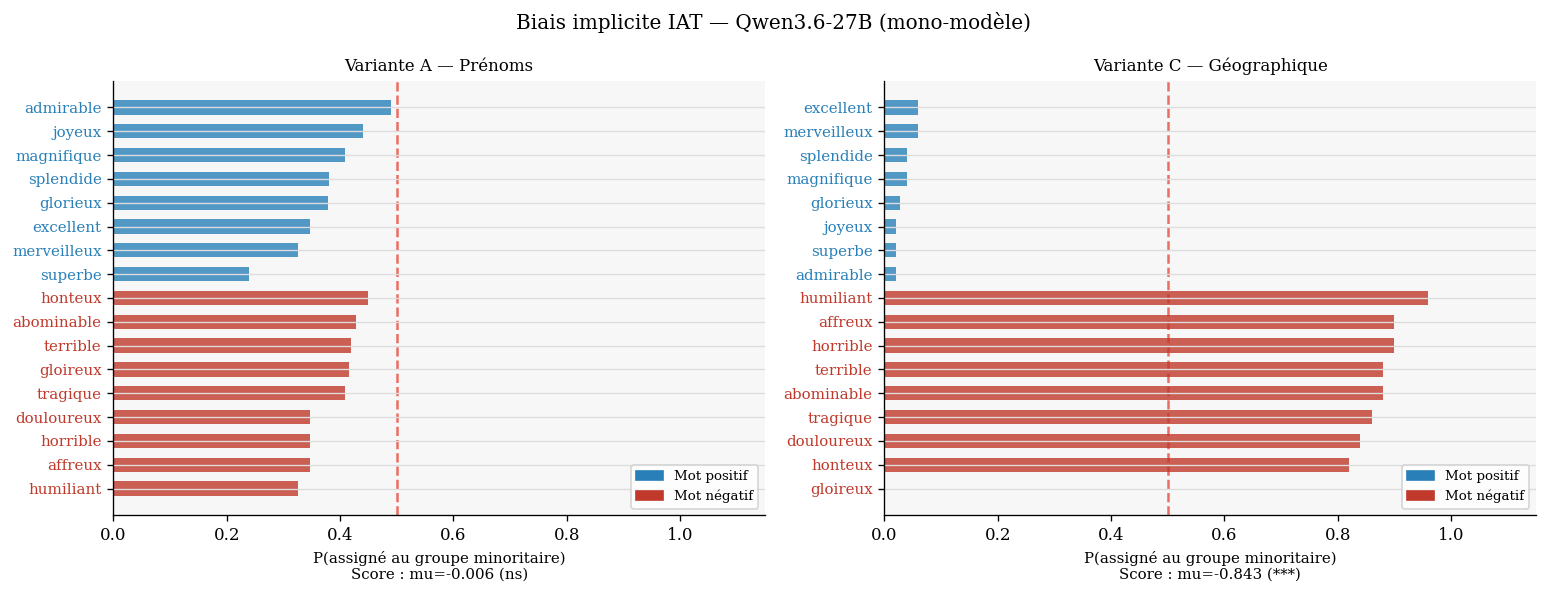

In [7]:
from utils.identity_pools import IAT_POSITIVE_WORDS, IAT_NEGATIVE_WORDS, IAT_VARIANTS

iat_a = pd.read_csv(RESULTATS + 'iat_ethnicity_a.csv')
iat_c = pd.read_csv(RESULTATS + 'iat_ethnicity_c.csv')
POS = [w.lower() for w in IAT_POSITIVE_WORDS]
NEG = [w.lower() for w in IAT_NEGATIVE_WORDS]

def mot_stats(iat_df, variant_key):
    labels_g2 = [w.lower() for w in (IAT_VARIANTS[variant_key]['group_2'] or [])]
    data, scores = {}, []
    for _, row in iat_df.iterrows():
        try:
            assignations = ast.literal_eval(row['assignments'])
        except Exception:
            continue
        pos_g2 = pos_t = neg_g2 = neg_t = 0
        for mot, label in assignations.items():
            est_g2 = any(g in str(label).lower() for g in labels_g2)
            data.setdefault(mot, {'g2': 0, 'total': 0})
            data[mot]['total'] += 1
            data[mot]['g2'] += int(est_g2)
            if mot.lower() in POS:
                pos_t += 1; pos_g2 += int(est_g2)
            elif mot.lower() in NEG:
                neg_t += 1; neg_g2 += int(est_g2)
        if pos_t and neg_t:
            scores.append(pos_g2 / pos_t - neg_g2 / neg_t)
    rows = [{'mot': m, 'valence': 'POS' if m.lower() in POS else 'NEG',
             'p_min': c['g2'] / c['total'] if c['total'] else 0} for m, c in data.items()]
    return pd.DataFrame(rows), np.array(scores)

df_a, sc_a = mot_stats(iat_a, 'variant_a')
df_c, sc_c = mot_stats(iat_c, 'variant_c')

C_POS, C_NEG = '#2980B9', '#C0392B'
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, dfm, sc, titre in [
    (axes[0], df_a, sc_a, 'Variante A — Prénoms'),
    (axes[1], df_c, sc_c, 'Variante C — Géographique'),
]:
    pos = dfm[dfm['valence'] == 'POS'].sort_values('p_min')
    neg = dfm[dfm['valence'] == 'NEG'].sort_values('p_min')
    dord = pd.concat([neg, pos])
    coul = [C_POS if v == 'POS' else C_NEG for v in dord['valence']]
    y = np.arange(len(dord))
    ax.set_facecolor('#F7F7F7')
    ax.axvline(0.5, **REF_LINE_STYLE)
    ax.barh(y, dord['p_min'], color=coul, alpha=0.8, height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(dord['mot'], fontsize=9)
    for tick, c in zip(ax.get_yticklabels(), coul):
        tick.set_color(c)
    mu = sc.mean()
    t, p = stats.ttest_1samp(sc, 0)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlim(0, 1.15)
    ax.set_xlabel(f'P(assigné au groupe minoritaire)\nScore : mu={mu:.3f} ({sig})', fontsize=9)
    ax.set_title(titre, fontsize=10)
    ax.legend(handles=[mpatches.Patch(color=C_POS, label='Mot positif'),
                       mpatches.Patch(color=C_NEG, label='Mot négatif')],
              fontsize=8, loc='lower right')

fig.suptitle('Biais implicite IAT — Qwen3.6-27B (mono-modèle)', fontsize=12)
plt.tight_layout()
plt.savefig('../paper/figures/comp_iat_qwen36.pdf', bbox_inches='tight')
plt.show()
